# Ensemble Fraud Detection Model

This notebook combines predictions from XGBoost, LightGBM, and Neural Network models.

The objective is to evaluate whether combining multiple model families improves fraud detection performance and reduces false positives compared to individual models.

In [3]:
import pandas as pd
df = pd.read_csv("../data/raw/DataSet.csv")

## Loading Model Predictions

Predicted probabilities generated by the XGBoost, LightGBM, and Neural Network models are loaded and aligned using account identifiers.

In [4]:
xgb = pd.read_csv("../data/processed/xgb_probs.csv", index_col=0)
lgbm = pd.read_csv("../data/processed/lgbm_probs.csv", index_col=0)
nn = pd.read_csv("../data/processed/nn_probs.csv", index_col=0)

## Ensemble Construction

Three ensemble strategies are evaluated:

- Average probability
- Weighted average probability
- Maximum probability

These approaches combine information from multiple model families while preserving model diversity.

In [5]:
xgb.columns = ["xgb"]
lgbm.columns = ["lgbm"]
nn.columns = ["nn"]

In [6]:
ensemble = pd.concat(
    [xgb, lgbm, nn],
    axis=1
)

In [7]:
ensemble["avg"] = (
    ensemble["xgb"] +
    ensemble["lgbm"] +
    ensemble["nn"]
) / 3

In [8]:
ensemble["prob"] = (
    0.4 * ensemble["xgb"]
    + 0.4 * ensemble["lgbm"]
    + 0.2 * ensemble["nn"]
)

In [9]:
ensemble["max"] = ensemble[
    ["xgb","lgbm","nn"]
].max(axis=1)

## Evaluation Data

Ground-truth labels from the test set are loaded and merged with the ensemble predictions.

In [10]:
actual = pd.read_csv(
    "../data/processed/y_test.csv",
    index_col=0
)

ensemble = ensemble.join(actual)

In [11]:
pred = (ensemble["prob"] >= 0.25).astype(int)

## Classification Performance

The weighted-average ensemble is evaluated using a probability threshold of 0.25.

This threshold was selected to prioritize fraud recall while controlling false positives.

In [12]:
from sklearn.metrics import classification_report

pred = (ensemble["avg"] >= 0.25).astype(int)

print(
    classification_report(
        ensemble["actual"],
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1801
           1       0.05      0.81      0.09        16

    accuracy                           0.86      1817
   macro avg       0.52      0.84      0.51      1817
weighted avg       0.99      0.86      0.92      1817



## Confusion Matrix

The confusion matrix summarizes the number of correctly detected frauds, missed frauds, and false-positive alerts generated by the ensemble.

In [13]:
from sklearn.metrics import confusion_matrix

pred = (ensemble["avg"] >= 0.25).astype(int)

cm = confusion_matrix(
    ensemble["actual"],
    pred
)

print(cm)

[[1550  251]
 [   3   13]]


## Key Findings

The ensemble successfully combined information from multiple model families and achieved strong fraud detection performance.

Key observations:

- The ensemble detected 13 out of 16 fraud cases.
- False positives were reduced compared to the standalone Neural Network model.
- Combining tree-based and neural approaches improved prediction stability.
- The ensemble provided a stronger precision-recall tradeoff than several individual models.

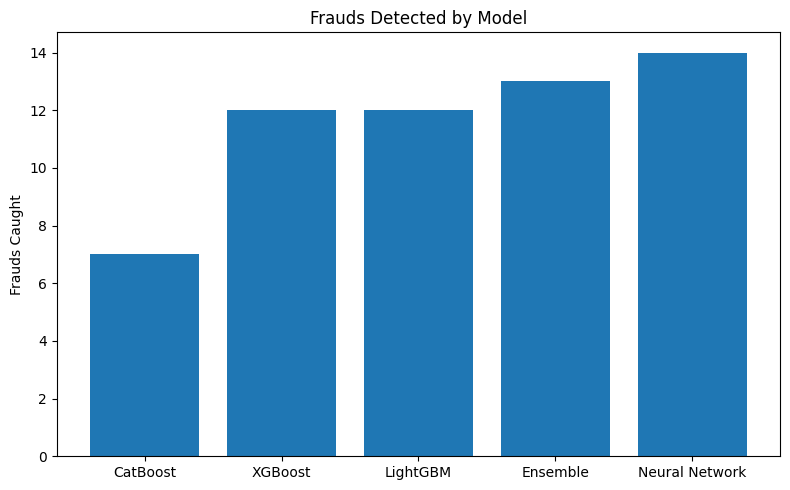

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM",
        "Ensemble",
        "Neural Network"
    ],
    "Frauds Caught": [
        7,
        12,
        12,
        13,
        14
    ]
})

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Frauds Caught"]
)

plt.title("Frauds Detected by Model")
plt.ylabel("Frauds Caught")

plt.tight_layout()
plt.show()

In [15]:
plt.savefig(
    "../figures/model_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>